# Probe prediction analysis

Visualizes the probe predictions in `processed_datasets/*_predictions.csv`.

Each predictions file corresponds to one (dataset, layer) pair and contains, per statement:
the true `label`, the probability from each of the 10 trained probes (`model_i_probability`),
and their ensemble `average_probability`.

Charts produced:
1. Ensemble accuracy and AUC vs. layer, per dataset
2. Per-probe spread (how much the 10 probes disagree) vs. layer
3. Predicted-probability distributions by true label, per layer
4. ROC curves across layers
5. Calibration at the best layer
6. Most confidently wrong statements at the best layer

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATASET_COLORS = {"facts": "#4C72B0", "companies": "#DD8452"}


def color_for(dataset):
    return DATASET_COLORS.get(dataset, "#55A868")

## Load predictions

The `embeddings` column is huge and not needed for analysis, so it is skipped on read.

In [2]:
DATA_DIR = Path("processed_datasets")
PATTERN = re.compile(r"embeddings_(?P<dataset>.+?)Qwen3-14B_(?P<layer>\d+)_rmv_period_predictions\.csv")

files = {}
for path in sorted(DATA_DIR.glob("*_predictions.csv")):
    m = PATTERN.match(path.name)
    if m:
        files[(m["dataset"], int(m["layer"]))] = path

datasets = sorted({ds for ds, _ in files})
layers = sorted({layer for _, layer in files})
print(f"datasets: {datasets}")
print(f"layers:   {layers}")

preds = {
    key: pd.read_csv(path, usecols=lambda c: c != "embeddings")
    for key, path in files.items()
}
MODEL_COLS = [c for c in next(iter(preds.values())).columns if c.startswith("model_")]
print(f"{len(preds)} files loaded, {len(MODEL_COLS)} probes per layer")

datasets: ['companies', 'facts']
layers:   [1, 4, 8, 12, 16, 20, 24, 28]
16 files loaded, 10 probes per layer


## Compute metrics

For the ensemble (`average_probability`) and each individual probe we compute AUC,
accuracy at a fixed 0.5 threshold, and accuracy at the optimal threshold (chosen by
maximizing accuracy over the ROC thresholds, as in `TrainProbes.py`).

**Caveat:** the optimal threshold is chosen on the same data it is evaluated on, so
`acc_opt` is slightly optimistic; treat it as an upper bound on separability, and AUC
as the threshold-free comparison.

In [3]:
def optimal_threshold_accuracy(y, p):
    _, _, thresholds = roc_curve(y, p)
    accs = [accuracy_score(y, p > thr) for thr in thresholds]
    best = int(np.argmax(accs))
    return accs[best], thresholds[best]


def metrics_for(y, p):
    acc_opt, thr = optimal_threshold_accuracy(y, p)
    return {
        "auc": roc_auc_score(y, p),
        "acc_05": accuracy_score(y, p > 0.5),
        "acc_opt": acc_opt,
        "threshold": thr,
    }


ensemble_rows, probe_rows = [], []
for (ds, layer), df in preds.items():
    y = df["label"].to_numpy()
    ensemble_rows.append(
        {"dataset": ds, "layer": layer, **metrics_for(y, df["average_probability"].to_numpy())}
    )
    for col in MODEL_COLS:
        probe_rows.append(
            {"dataset": ds, "layer": layer, "probe": col, **metrics_for(y, df[col].to_numpy())}
        )

ensemble = pd.DataFrame(ensemble_rows).sort_values(["dataset", "layer"]).reset_index(drop=True)
probes = pd.DataFrame(probe_rows).sort_values(["dataset", "layer", "probe"]).reset_index(drop=True)
ensemble

,dataset,layer,auc,acc_05,acc_opt,threshold
0,companies,1,0.740990,0.660000,0.665833,0.3568
1,companies,4,0.787969,0.677500,0.714167,0.3706
2,companies,8,0.827821,0.721667,0.758333,0.0801
3,companies,12,0.886207,0.782500,0.826667,0.2082
4,companies,16,0.885101,0.763333,0.847500,0.2077
5,companies,20,0.898604,0.790000,0.839167,0.1188
6,companies,24,0.825612,0.657500,0.772500,0.0138
7,companies,28,0.830033,0.746667,0.756667,0.3978
8,facts,1,0.915487,0.816993,0.844771,0.7011
9,facts,4,0.933332,0.851307,0.867647,0.7447


## 1. Ensemble accuracy and AUC vs. layer

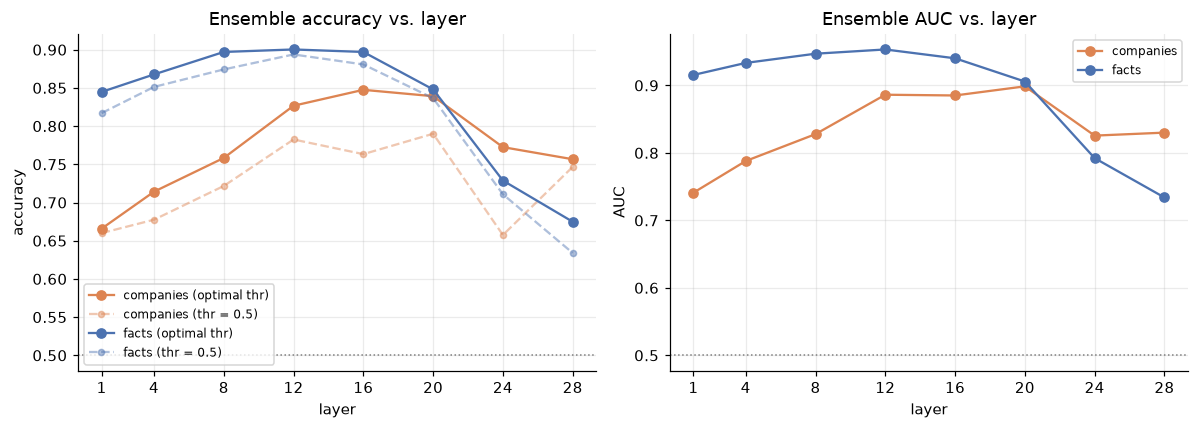

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

for ds in datasets:
    sub = ensemble[ensemble["dataset"] == ds]
    c = color_for(ds)
    axes[0].plot(sub["layer"], sub["acc_opt"], "-o", color=c, label=f"{ds} (optimal thr)")
    axes[0].plot(sub["layer"], sub["acc_05"], "--o", color=c, alpha=0.45, markersize=4, label=f"{ds} (thr = 0.5)")
    axes[1].plot(sub["layer"], sub["auc"], "-o", color=c, label=ds)

axes[0].axhline(0.5, color="gray", lw=1, ls=":")
axes[0].set(title="Ensemble accuracy vs. layer", xlabel="layer", ylabel="accuracy")
axes[0].legend(fontsize=8)
axes[1].axhline(0.5, color="gray", lw=1, ls=":")
axes[1].set(title="Ensemble AUC vs. layer", xlabel="layer", ylabel="AUC")
axes[1].legend(fontsize=8)
axes[0].set_xticks(layers)
fig.tight_layout()
plt.show()

## 2. Per-probe spread vs. layer

Each dot is one of the 10 probes; the line is the ensemble. Tight clusters mean the
probes agree; wide spread means training runs landed on different solutions.

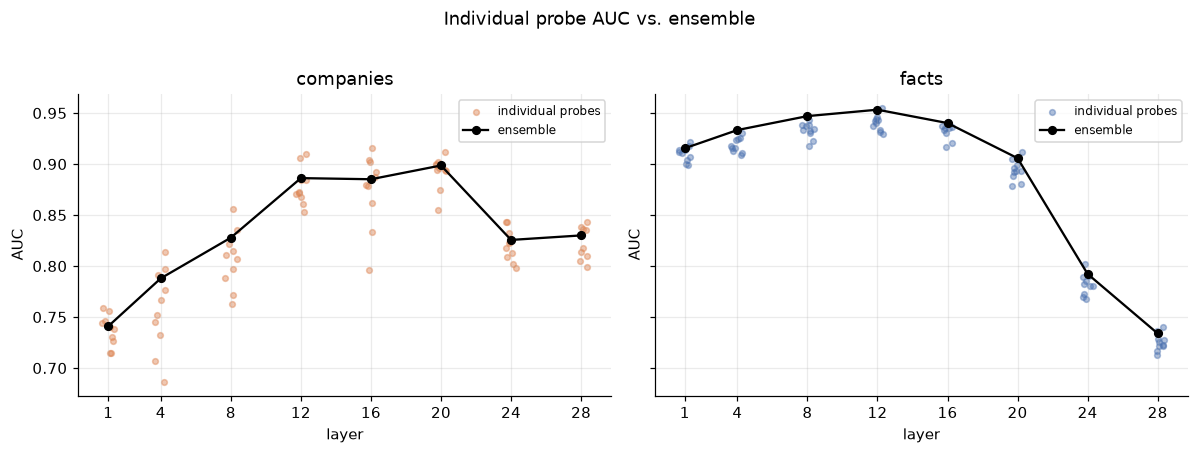

In [5]:
fig, axes = plt.subplots(1, len(datasets), figsize=(5.5 * len(datasets), 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, ds in zip(axes, datasets):
    c = color_for(ds)
    sub_p = probes[probes["dataset"] == ds]
    sub_e = ensemble[ensemble["dataset"] == ds]
    jitter = np.random.default_rng(0).uniform(-0.35, 0.35, len(sub_p))
    ax.scatter(sub_p["layer"] + jitter, sub_p["auc"], s=14, color=c, alpha=0.45, label="individual probes")
    ax.plot(sub_e["layer"], sub_e["auc"], "-o", color="black", lw=1.5, markersize=5, label="ensemble")
    ax.set(title=ds, xlabel="layer", ylabel="AUC")
    ax.set_xticks(layers)
    ax.legend(fontsize=8)

fig.suptitle("Individual probe AUC vs. ensemble", y=1.02)
fig.tight_layout()
plt.show()

## 3. Predicted-probability distributions by true label

Good separation shows up as true statements (label 1) piling near 1 and false ones near 0.

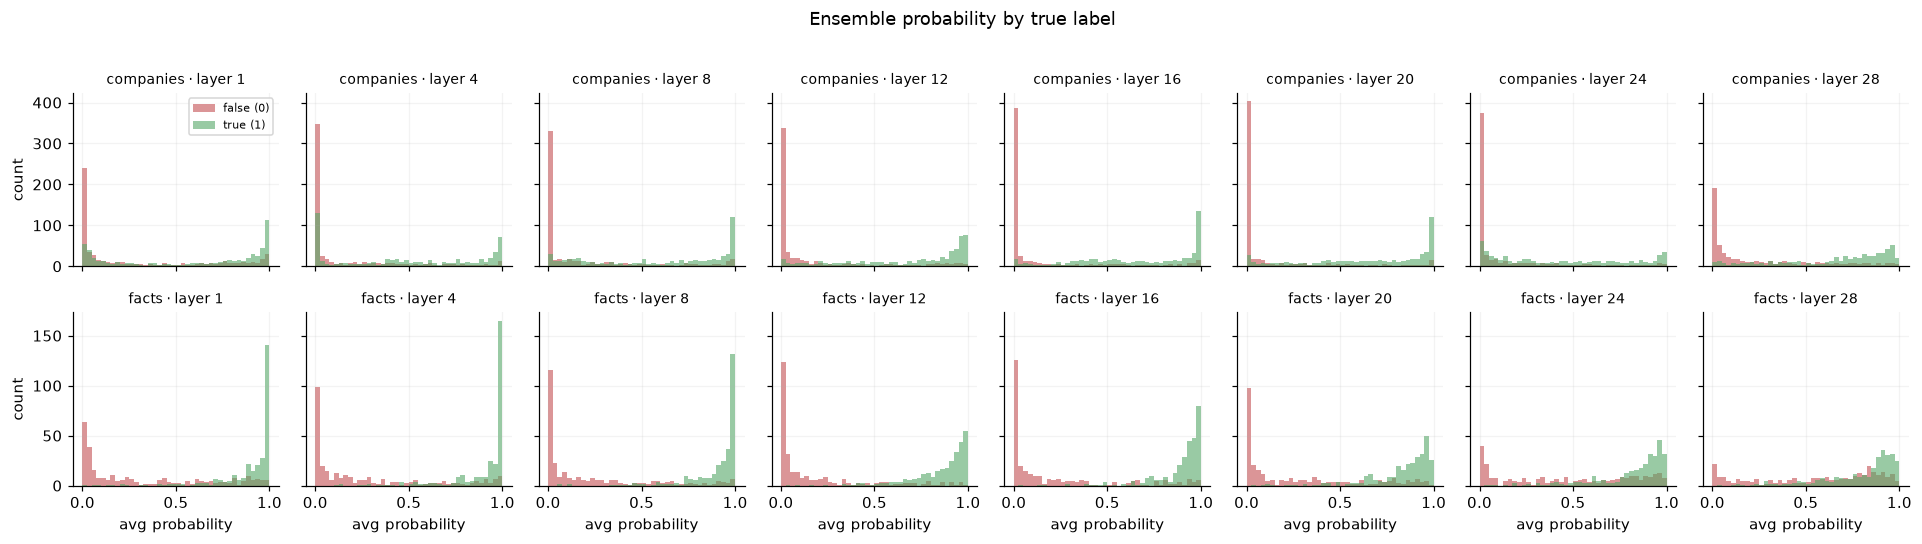

In [6]:
bins = np.linspace(0, 1, 41)
fig, axes = plt.subplots(len(datasets), len(layers), figsize=(2.2 * len(layers), 2.4 * len(datasets)),
                         sharex=True, sharey="row")
axes = np.atleast_2d(axes)

for i, ds in enumerate(datasets):
    for j, layer in enumerate(layers):
        ax = axes[i, j]
        df = preds[(ds, layer)]
        p = df["average_probability"]
        ax.hist(p[df["label"] == 0], bins=bins, alpha=0.6, color="#C44E52", label="false (0)")
        ax.hist(p[df["label"] == 1], bins=bins, alpha=0.6, color="#55A868", label="true (1)")
        ax.set_title(f"{ds} · layer {layer}", fontsize=9)
        ax.grid(alpha=0.15)
        if j == 0:
            ax.set_ylabel("count")
        if i == len(datasets) - 1:
            ax.set_xlabel("avg probability")

axes[0, 0].legend(fontsize=7)
fig.suptitle("Ensemble probability by true label", y=1.02)
fig.tight_layout()
plt.show()

## 4. ROC curves across layers

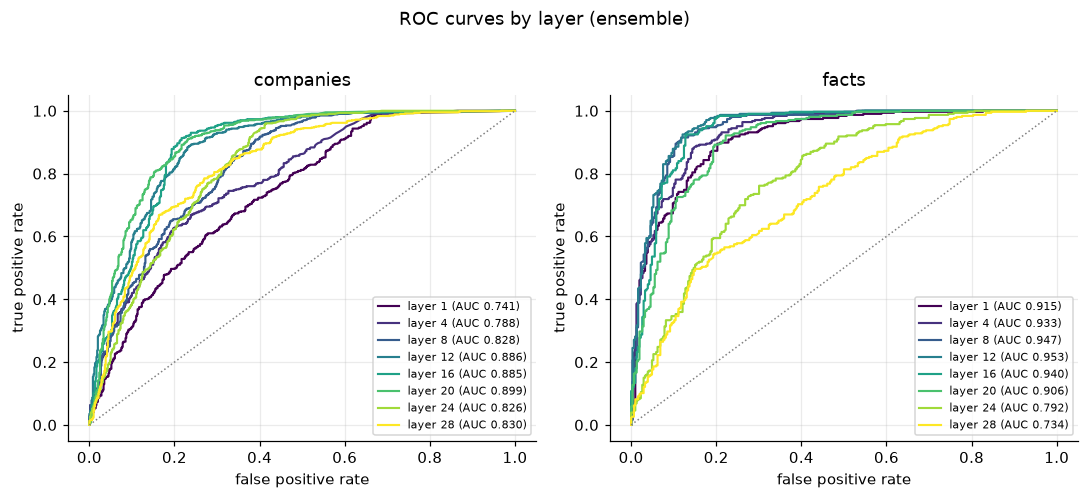

In [7]:
cmap = plt.get_cmap("viridis")
fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4.4))
axes = np.atleast_1d(axes)

for ax, ds in zip(axes, datasets):
    for k, layer in enumerate(layers):
        df = preds[(ds, layer)]
        fpr, tpr, _ = roc_curve(df["label"], df["average_probability"])
        auc = roc_auc_score(df["label"], df["average_probability"])
        ax.plot(fpr, tpr, color=cmap(k / max(len(layers) - 1, 1)), lw=1.4,
                label=f"layer {layer} (AUC {auc:.3f})")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, ls=":")
    ax.set(title=ds, xlabel="false positive rate", ylabel="true positive rate")
    ax.legend(fontsize=7, loc="lower right")

fig.suptitle("ROC curves by layer (ensemble)", y=1.02)
fig.tight_layout()
plt.show()

## 5. Calibration at the best layer

Best layer = highest ensemble AUC per dataset. A well-calibrated probe tracks the diagonal.

best layers by AUC: {'companies': 20, 'facts': 12}


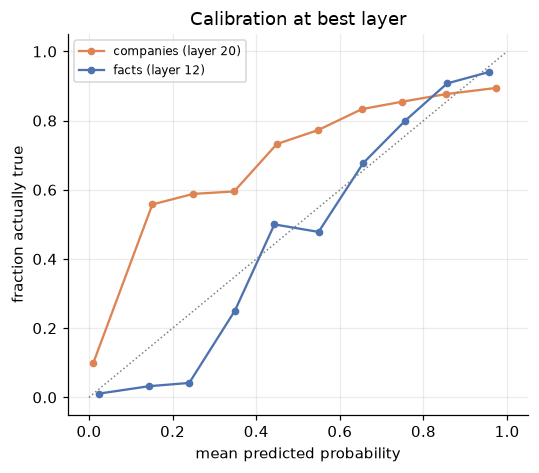

In [8]:
best_layer = {
    ds: int(ensemble[ensemble["dataset"] == ds].sort_values("auc").iloc[-1]["layer"])
    for ds in datasets
}
print(f"best layers by AUC: {best_layer}")

fig, ax = plt.subplots(figsize=(5, 4.4))
for ds in datasets:
    df = preds[(ds, best_layer[ds])]
    frac_pos, mean_pred = calibration_curve(df["label"], df["average_probability"], n_bins=10)
    ax.plot(mean_pred, frac_pos, "-o", color=color_for(ds), markersize=4,
            label=f"{ds} (layer {best_layer[ds]})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, ls=":")
ax.set(title="Calibration at best layer", xlabel="mean predicted probability",
       ylabel="fraction actually true")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Most confidently wrong statements at the best layer

Statements where the ensemble is most confident in the wrong direction — useful for
spotting labeling errors or systematic blind spots.

In [9]:
pd.set_option("display.max_colwidth", 120)

for ds in datasets:
    df = preds[(ds, best_layer[ds])].copy()
    df["error"] = (df["label"] - df["average_probability"]).abs()
    worst = df.sort_values("error", ascending=False).head(10)
    print(f"\n=== {ds} · layer {best_layer[ds]} — top 10 confidently wrong ===")
    display(worst[["statement", "label", "average_probability"]].reset_index(drop=True))


=== companies · layer 20 — top 10 confidently wrong ===


,statement,label,average_probability
0,Airbus Group has headquarters in Netherlands.,1,0.0000
1,British American Tobacco has headquarters in United States.,1,0.0000
2,Stellantis has headquarters in Netherlands.,1,0.0001
3,Hitachi has headquarters in United States.,1,0.0003
4,Merck & Co. operates in the industry of united states.,1,0.0003
5,Linde has headquarters in United Kingdom.,1,0.0003
6,Univlever has headquarters in United Kingdom.,1,0.0005
7,ENGIE operates in the industry of oil & gas operations.,1,0.0006
8,Canadian Imperial Bank of Commerce engages in the provision of banking and financial services.,0,0.9994
9,Santander engages in the provision of banking and financial services.,0,0.9994



=== facts · layer 12 — top 10 confidently wrong ===


,statement,label,average_probability
0,Cells are the complex units of life.,0,0.9895
1,The process by which plants release oxygen and absorb carbon dioxide is called respiration.,1,0.0329
2,Atoms are the basic breaking points of matter.,0,0.9645
3,Neurons are generalized cells that block electrical and chemical signals in the nervous system.,0,0.9603
4,The largest volcano in the world is located in Hawaii.,0,0.9580
5,The Nile River is the longest river in the world.,0,0.9503
6,The Earth is the only planet in the solar system.,0,0.9252
7,A substance that can be broken down into simpler substances by chemical means is called a compound.,0,0.9242
8,The human eye can detect millions of different colors.,1,0.0831
9,"The three types of air vessels in the human body are arteries, veins, and capillaries.",0,0.9102
